---
title: Moments and distributions
---

In [1]:
from phasic import Graph, with_ipv # ALWAYS import phasic first to set jax backend correctly
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
sns.set_palette('tab10')
from vscodenb import set_vscode_theme
set_vscode_theme()
np.random.seed(42)
_pytest = "pytest" in sys.modules

Construct a graph:

In [2]:
nr_samples = 4

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i+j+1] += 1
            transitions.append((new, state[i]*(state[j]-same)/(1+same)))
    return transitions

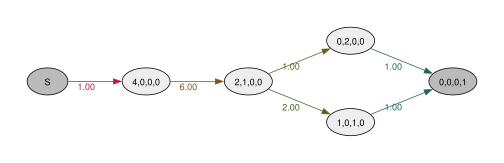

In [3]:
graph = Graph(coalescent)
graph.plot()

Show states nicely as data frame:

In [4]:
labels = [f"{i+1}'ton" for i in range(nr_samples)]

pd.DataFrame(graph.states(), columns=labels)

,1'ton,2'ton,3'ton,4'ton
0,0,0,0,0
1,4,0,0,0
2,2,1,0,0
3,0,2,0,0
4,1,0,1,0
5,0,0,0,1


This phase-type distribution models the time until all lineages have coalesced. For convenience, we can get its expectation and variance like this:

In [5]:
graph.expectation()

1.4999999999999996

In [6]:
#| echo: false
if _pytest: assert graph.expectation() == pytest.approx(1.5)

In [7]:
#| echo: false
if _pytest: assert pytest.approx(graph.expectation()) == 1.5

In [8]:
graph.variance()

1.1388888888888893

In [9]:
#| echo: false
if _pytest: assert pytest.approx(graph.variance()) == 1.1388888

But if you want you can get any number of moments like this (here three):

In [10]:
graph.moments(3)

[1.4999999999999996, 3.388888888888888, 10.583333333333332]

In [11]:
from phasic import Graph
g = Graph(1)
v1 = g.find_or_create_vertex([1])
g.starting_vertex().add_edge(v1, 1)
v2 = g.find_or_create_vertex([2])
v1.add_edge(v2, 1)
v3 = g.find_or_create_vertex([3])
v2.add_edge(v3, 1)
v4 = g.find_or_create_vertex([4])
v3.add_edge(v4, 1)
g.plot()
ew = g.expected_waiting_time(), 
ew, g.expectation()

(([3.0, 3.0, 2.0, 1.0, 0.0],), 3.0)

In [12]:
g.expected_waiting_time(ew[0]), g.variance()

([6.0, 6.0, 3.0, 1.0, 0.0], 3.0)

In [13]:
g.moments(3)

[3.0, 12.0, 60.0]

We can find the expected waiting time given that we start in any of the states, not just the starting state:        

In [14]:
graph.expected_waiting_time()

[1.4999999999999996, 1.4999999999999996, 1.333333333333333, 1.0, 1.0, 0.0]

Expected time spent in each state (exact):

In [15]:
graph.expected_sojourn_time()

[0.0,
 0.16666666666666663,
 0.33333333333333326,
 0.3333333333333333,
 0.6666666666666666,
 0.0]

Expected time spent in each state after some time:

In [16]:
graph.accumulated_occupancy

<bound method Graph.accumulated_occupancy of <Graph (6 vertices)>>

We can get the CDF and PDF. The distribution methods reuse cached computations and recompute only if the graph changes. Compare the running times for the first and second call to the function:

In [17]:
time = np.arange(0, 4, 0.001)

In [18]:
%%time
cdf = graph.cdf(time)

CPU times: user 212 μs, sys: 33 μs, total: 245 μs
Wall time: 247 μs


In [19]:
%%time
cdf = graph.cdf(time)

CPU times: user 28 μs, sys: 1 μs, total: 29 μs
Wall time: 30.3 μs


Plot PDF and CDF:

<Figure size 640x480 with 0 Axes>

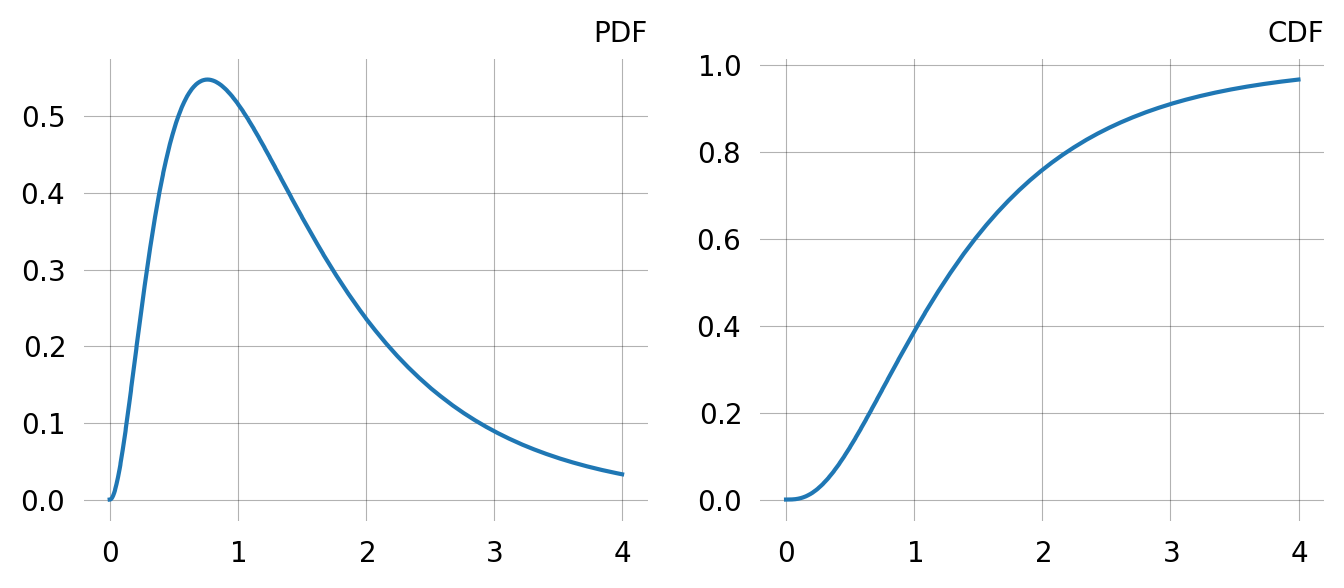

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
ax1.plot(time, graph.pdf(time))
ax1.set_title("PDF")
ax2.plot(time, graph.cdf(time))
ax2.set_title("CDF") ;

# Rewards

We can add rewards which are based on the number of doubletons:

In [21]:
graph = Graph(coalescent)
reward_matrix = graph.states().T
doubletons = reward_matrix[1]
doubletons

array([0, 0, 1, 2, 0, 0], dtype=int32)

Adding these rewards, the phase-type distribution now represent the total doubleton branch length (total length of branches with two descendants). The expectation and variance are now:

In [22]:
graph.expectation(doubletons), graph.variance(doubletons)

(0.9999999999999999, 2.333333333333333)

Using rewards to the moment functions etc. is much faster than changing the graph. Here is the SFS (Site Frequency Spectrum) computed in this way. The 4'ton is included to illustrate that it is represented but has expectation zero since this it the absorbing TMRCA.

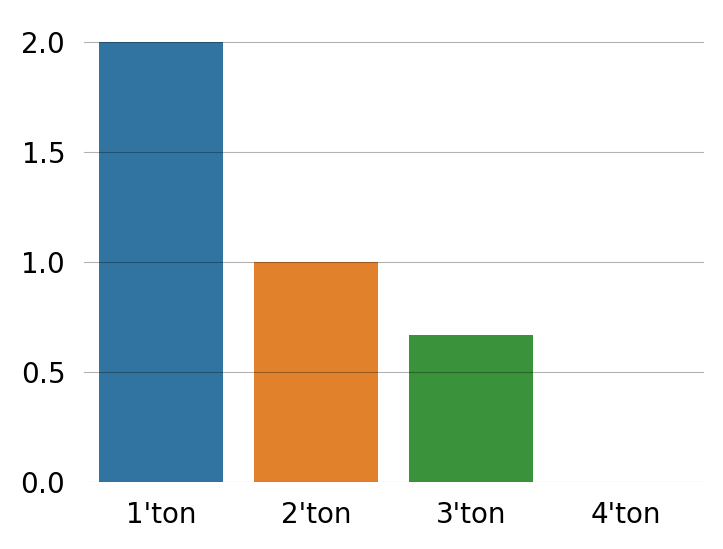

In [23]:
labels = [f"{i+1}'ton" for i in range(reward_matrix.shape[0])]
sfs = [graph.expectation(r) for r in reward_matrix]
plt.figure(figsize=(4, 3))
sns.barplot(x=labels, y=sfs, hue=labels) ;

And here by doing each reward_transform:

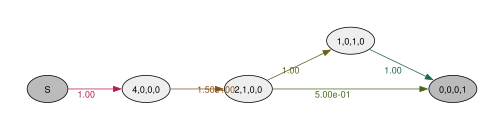

In [24]:
singleton_graph = graph.reward_transform(reward_matrix[0])
singleton_graph.plot()

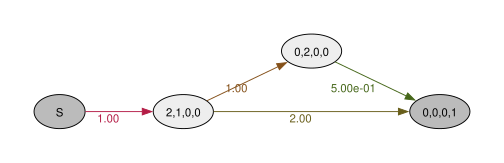

In [25]:
doubleton_graph = graph.reward_transform(reward_matrix[1])
doubleton_graph.plot()

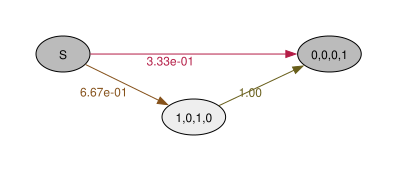

In [26]:
tripleton_graph = graph.reward_transform(reward_matrix[2])
tripleton_graph.plot()

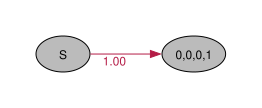

In [27]:
quadrupleton_graph = graph.reward_transform(reward_matrix[3])
quadrupleton_graph.plot()

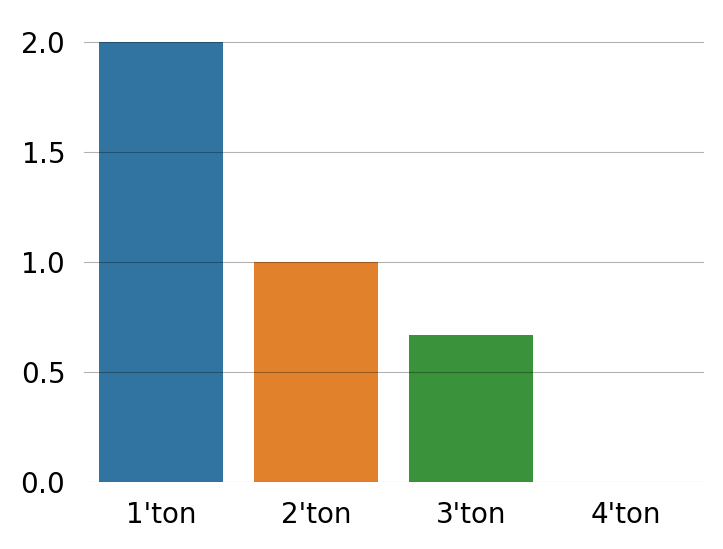

In [28]:
sfs = [
    singleton_graph.expectation(),
    doubleton_graph.expectation(),
    tripleton_graph.expectation(),
    quadrupleton_graph.expectation()
]
plt.figure(figsize=(4, 3))
sns.barplot(x=labels, y=sfs, hue=labels) ;

Computing the (unrewarded) expectation on the reward-transforming graph produces the same result as passing the rewards to `expectation`, but is much slower:

In [29]:
graph = Graph(coalescent)
singleton_rewards = graph.states().T[0]

In [30]:
%%timeit
graph.expectation(singleton_rewards)

5.12 μs ± 568 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [31]:
%%timeit
graph.reward_transform(singleton_rewards).expectation()

19.9 μs ± 382 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


The real use of reward transformation is that it provides the full distribution of accumulated rewards. For example if we want the PDF/CDF.

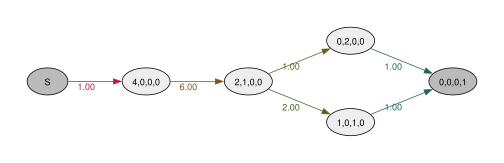

In [32]:
graph = Graph(coalescent)
graph.plot()

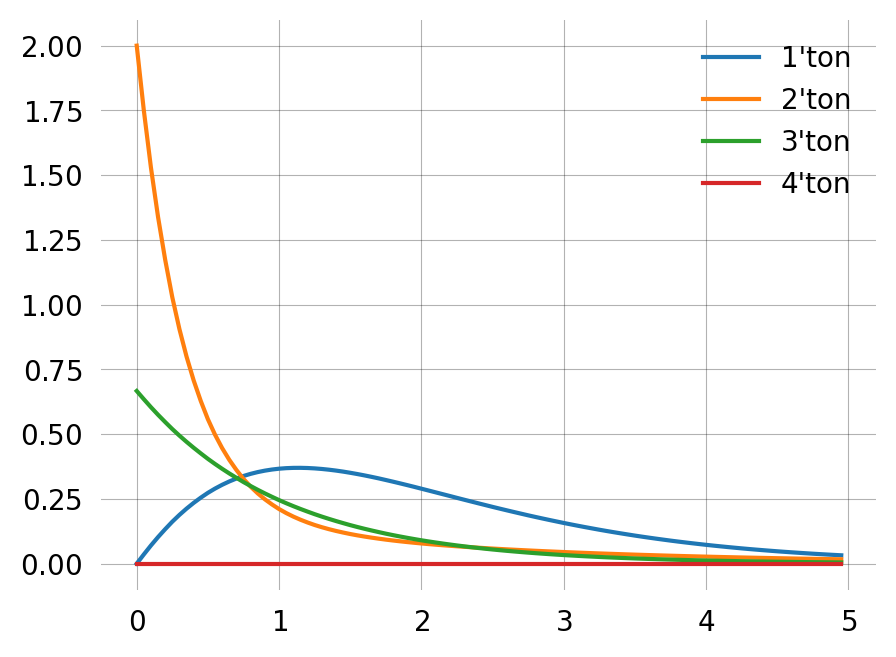

In [33]:
times = np.arange(0, 5, 0.05)
reward_matrix = graph.states().T
labels = [f"{i+1}'ton" for i in range(reward_matrix.shape[1])]

for i, rewards in enumerate(reward_matrix):
    revt_graph = graph.reward_transform(rewards)
    plt.plot(times, revt_graph.pdf(times), label=labels[i])
plt.legend() ;

# State probability and occupancy

There are also utility methods to get the state probability i.e. probabilities of occupying each state at time t. 

In [34]:
graph = Graph(coalescent)

In [35]:
graph.state_probability(0.2)

[0.0,
 0.29978049956512576,
 0.4964527753776389,
 0.06299978987254216,
 0.12599957974508433,
 0.0]

We can use that to compute the expected number of lineages across time:

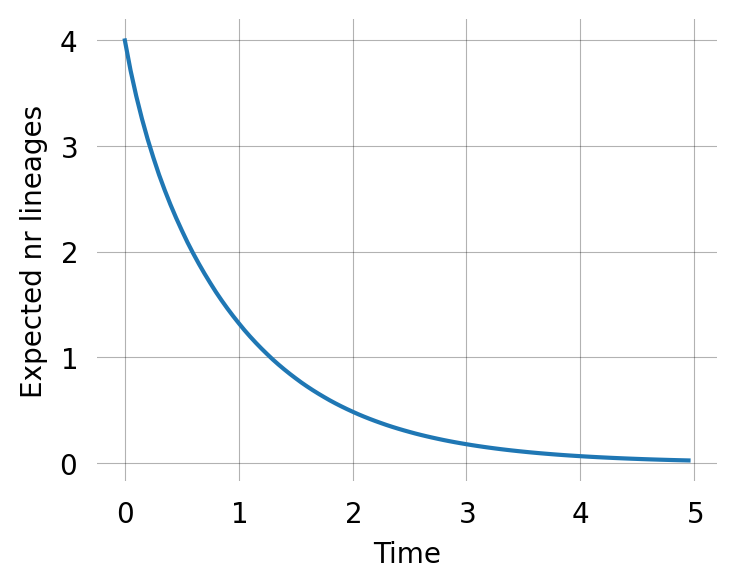

In [36]:
#| label: fig-tot-lineages-across-time
#| fig-cap: "Expected number of lineages across time."
#| fig-format: svg

times = np.arange(0, 5, 0.05)
expected_lineages_left = [
    np.sum(graph.state_probability(i) 
           * np.sum(graph.states(), axis=1)) 
    for i in times
    ]

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax.plot(times, expected_lineages_left)
ax.set_xlabel('Time')
ax.set_ylabel("Expected nr lineages") ;

The same way we can also compute the expected number of *each kind* of lineage across time:

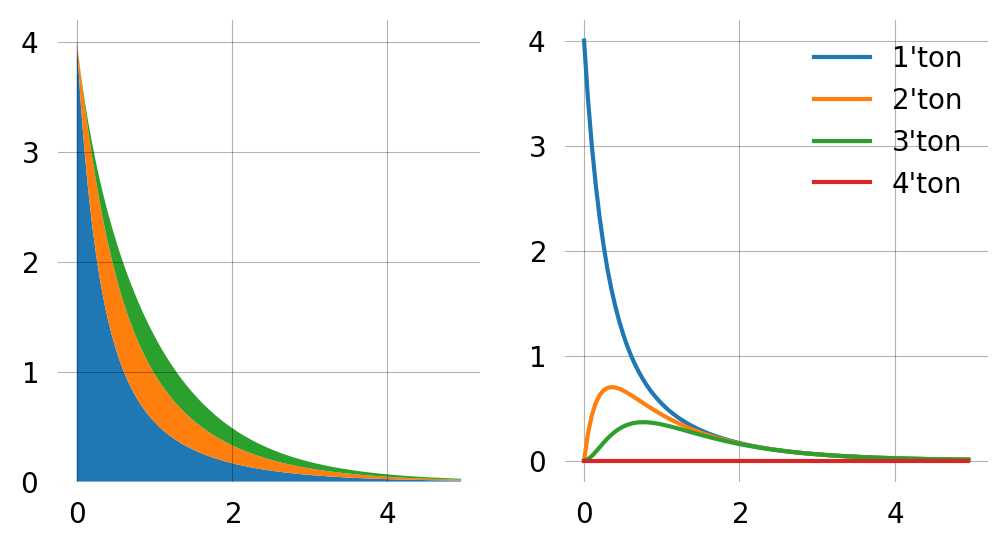

In [37]:
#| label: fig-ton-lineages-across-time
#| fig-cap: "Expected number of lineages across time."


times = np.arange(0, 5, 0.05)
state_probs = np.array([graph.state_probability(i) * graph.states().T for i in times])
labels = [f"{i+1}'ton" for i in range(state_probs.shape[1])]
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].stackplot(times, np.sum(state_probs, axis=2).T)
axes[1].plot(times, np.sum(state_probs, axis=2), label=labels)
# plt.subplot(121).stackplot(times, np.sum(state_probs, axis=2).T)
# plt.subplot(122).plot(times, np.sum(state_probs, axis=2), label=labels)
plt.legend() ;

We can also get the accumulated visiting time of a particular state. E.g. the total doubleton branchlength before time t=1.5:

In [38]:
rewards = (graph.states()[:,1]>0).astype(int)
np.sum(graph.accumulated_occupancy(time=1.5) * rewards)

np.float64(0.5293813150697056)

# Random sampling

The library includes functions to do random sampling. These are useful to also validate the computations

In [39]:
graph = Graph(coalescent)
graph.sample(5)

array([2.34879598, 0.51071083, 1.51249101, 0.56185111, 1.41002417])

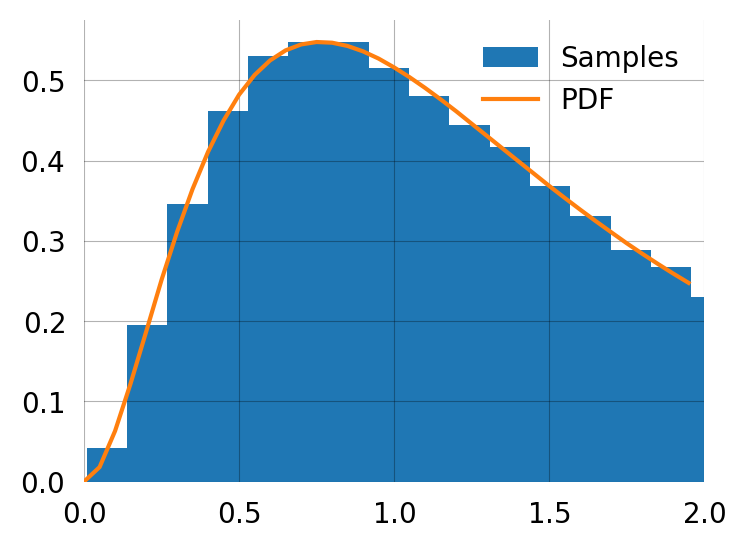

In [40]:
#| label: fig-tmrca-sampling-dist
#| fig-cap: "Sampling distribution."


fig, ax = plt.subplots(figsize=(4, 3))
samples = graph.sample(100000)

ax.hist(samples, bins=100, density=True, label='Samples')
x = np.arange(0, 2, 0.05)

ax.plot(x, [graph.pdf(t) for t in x], label='PDF')

ax.set_xlim(0, 2)
ax.legend();

You can produce the moments from sampling if needed. This is the empirical second moment computed from samples:

In [41]:
np.sum(np.array(graph.sample(10000))**2).item()/10000

3.342867086321454

Compare to the exact second moment:

In [42]:
graph.moments(2)[1]

3.388888888888888